In [28]:
import scanpy as sc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from anndata import AnnData
from scipy import sparse

In [30]:
ad = sc.read_h5ad("MAIT_NKT_gdT_paperlabels_exact.h5ad")
ad


AnnData object with n_obs × n_vars = 8253 × 25970
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'nGene', 'nUMI', 'use', 'final_celltype', 'major_type', 'paper_subtype', 'n_counts', 'n_genes', 'author_cluster', 'author_lineage', 'paper_cluster', 'paper_lineage'
    var: 'gene_symbols', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'gene_symbol'
    uns: 'log1p', 'paper_subtype_colors', 'umap_provenance'
    obsm: 'X_PCA', 'X_TSNE', 'X_umap'
    layers: 'counts'

In [31]:
print(f"Cell number is :{ad.shape[0]}")
print(f"Gene number is :{ad.shape[1]}")

Cell number is :8253
Gene number is :25970


In [32]:
alias = {"iNKT":"NKT", "γδT":"gdT"}
ad.obs["lineage_std"] = ad.obs["paper_lineage"].astype(str).replace(alias)
ad.obs["lineage_std"].value_counts()

NKT     3285
gdT     2681
MAIT    2287
Name: lineage_std, dtype: int64

# Adding celltype mapping with cluster names

In [36]:
map_nkt = {
    "N1":"NKTp", "N2":"NKT1", 
    "N3":"NKT2", "N4":"NKT2", "N5":"NKT2", "N6":"NKT2",
    "N7":"NKT17"
}

map_mait = {
    "M1":"S1", "M2":"S2", "M3":"S2", "M4":"S2",
    "M5":"MAIT1", "M6":"MAIT17i", "M7":"MAIT17i", "M8":"MAIT17"
}

map_gdt = {
    "G1":"gdTp", "G2":"gdT1i", "G3":"gdT1i",
    "G4":"gdT17i", "G5":"gdT17i",
    "G6-1":"gdT17", "G6-2":"gdT17",
    "G7-1":"gdT1i", "G7-2":"gdT1"
}

def cluster_to_subtype(cl):
    if not isinstance(cl,str): return "NA"
    if cl.startswith("N"): 
        return map_nkt.get(cl, "NA")
    if cl.startswith("M"): 
        return map_mait.get(cl, "NA")
    if cl.startswith("G"): 
        return map_gdt.get(cl, "NA")
    return "NA"

ad.obs["paper_subtype_strict"] = ad.obs["paper_cluster"].astype(str).map(cluster_to_subtype)


na_rows = ad.obs["paper_subtype_strict"].eq("NA").sum()
print("Subtype = 'NA' rows:", na_rows)


Subtype = 'NA' rows: 0


# UMAP on autor's coordinates

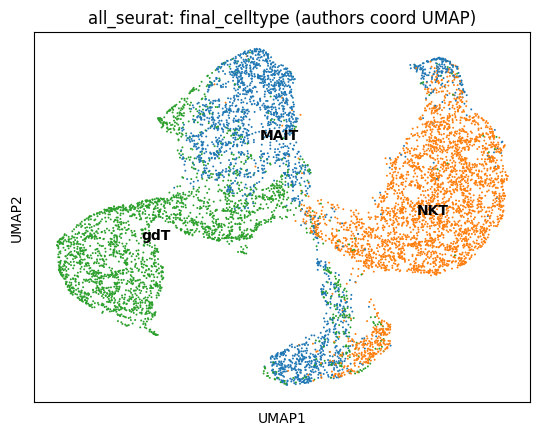

In [26]:
sc.pl.umap(
    ad, color="final_celltype", size=8, legend_loc="on data",
    title="all_seurat: final_celltype (authors coord UMAP)",
    save="authors_umap_final_celltype.png"
)

In [37]:
print("\nCounts by subtype_strict:")
display(ad.obs["paper_subtype_strict"].value_counts().sort_index())


Counts by subtype_strict:


MAIT1       148
MAIT17      464
MAIT17i     344
NKT1        210
NKT17       283
NKT2       2567
NKTp        225
S1          532
S2          799
gdT1         76
gdT17       230
gdT17i     1013
gdT1i      1052
gdTp        310
Name: paper_subtype_strict, dtype: int64

# UMAPs with strict cell types like fig 2 in paper

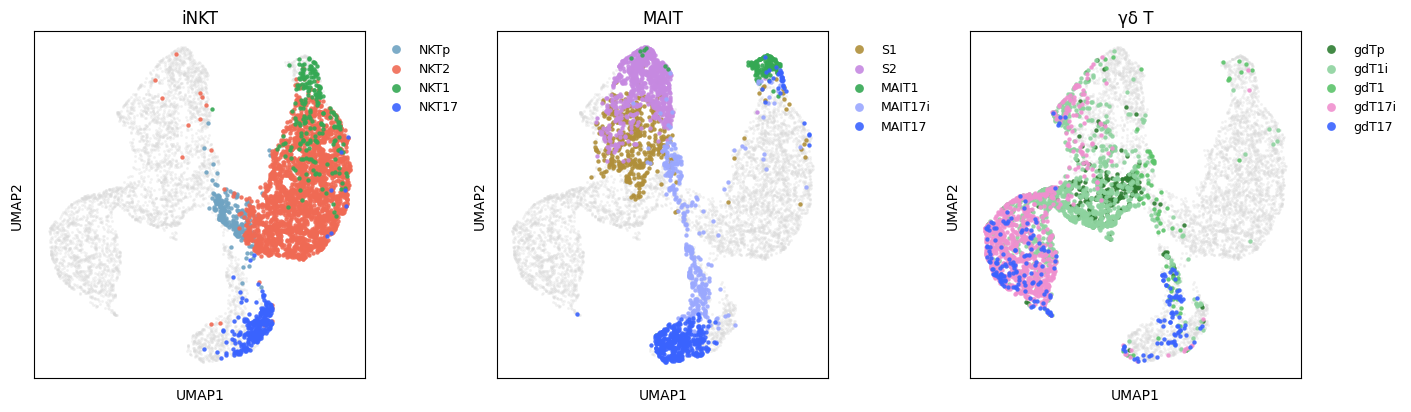

Saved: Fig2d_like_panels_CANONICAL.png


In [38]:
U = ad.obsm["X_umap"].copy()

pal_nkt  = {"NKT0":"#9BBBD5","NKTp":"#6FA3C2","NKT2":"#F06A54","NKT1":"#34A853","NKT17":"#3A63FF"}
pal_mait = {"S1":"#B08F3A","S2":"#C689E1","MAIT2":"#D64B3B","MAIT1":"#34A853","MAIT17":"#3A63FF","MAIT17i":"#9aa8ff","MAIT1i":"#7bd79b"}
pal_gdt  = {"gdTp":"#2E7D32","gdT1i":"#8ED39F","gdT1":"#5CC46B","gdT17i":"#F090CF","gdT17":"#3A63FF"}

def panel(ax, lineage, order, pal, title):
    ax.scatter(U[:,0], U[:,1], s=4, c="#D9D9D9", alpha=0.35, lw=0)
    m = ad.obs["lineage_std"].eq(lineage).values
    U_m = U[m]; subs = ad.obs.loc[m,"paper_subtype_strict"].astype(str).values
    for st in order:
        ms = (subs==st)
        if ms.sum()==0: continue
        ax.scatter(U_m[ms,0], U_m[ms,1], s=10, c=pal.get(st,"#555"), lw=0, alpha=0.9, label=st)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2"); 
    ax.legend(frameon=False, markerscale=2, fontsize=9, bbox_to_anchor=(1.02,1), loc="upper left")

fig, axes = plt.subplots(1,3, figsize=(14,4), constrained_layout=True)
panel(axes[0], "NKT",  ["NKT0","NKTp","NKT2","NKT1","NKT17"], pal_nkt,  "iNKT")
panel(axes[1], "MAIT", ["S1","S2","MAIT2","MAIT1","MAIT1i","MAIT17i","MAIT17"],   pal_mait, "MAIT")
panel(axes[2], "gdT",  ["gdTp","gdT1i","gdT1","gdT17i","gdT17"], pal_gdt, "γδ T")
plt.savefig("Fig2d_like_panels_CANONICAL.png", dpi=300, bbox_inches="tight")
plt.show()


# Trying to reconstruct these UMAPS using 5000 HVG

In [39]:
IN_H5AD = "MAIT_NKT_gdT_paperlabels_exact.h5ad" 
LINEAGE_COL  = "final_celltype"                   
SUBTYPE_COL  = "paper_subtype_strict"           
OUT_SHARED   = "fig_shared_umap_final_celltype.png"
OUT_PANELS   = "Fig2d_like_panels_SHARED.png"

ad = sc.read_h5ad(IN_H5AD)


# HVG selection 
ad.X = ad.layers["counts"].copy()
sc.pp.highly_variable_genes(ad, flavor="seurat_v3", layer="counts", n_top_genes=5000, inplace=True)

# normalized/log data 
ad_norm = ad.copy()
sc.pp.normalize_total(ad_norm, target_sum=1e4)
sc.pp.log1p(ad_norm)

ad_hvg = ad_norm[:, ad.var["highly_variable"]].copy()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/root/miniconda/envs/celloracle_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<AxesSubplot: title={'center': 'HVG-5000: final_celltypes'}, xlabel='UMAP1', ylabel='UMAP2'>

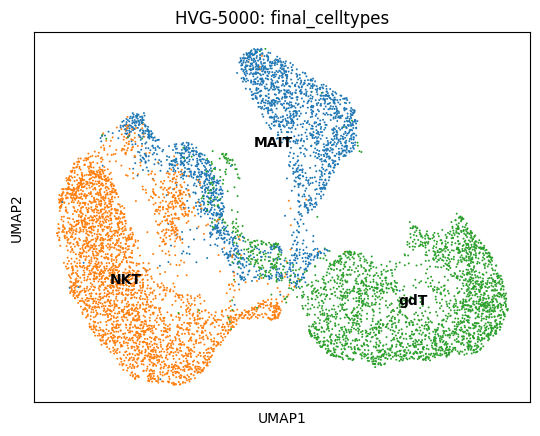

In [40]:
sc.tl.pca(ad_hvg, n_comps=5, svd_solver="arpack")
sc.pp.neighbors(ad_hvg, n_neighbors=40, metric="cosine")
sc.tl.umap(ad_hvg, min_dist=0.45)

sc.pl.umap(
    ad_hvg, color=[LINEAGE_COL], size=8, legend_loc="on data",
    title="HVG-5000: final_celltypes", show=False
)


In [43]:
map_nkt = {
    "N1":"NKTp", "N2":"NKT1", "N3":"NKT2", "N4":"NKT2",
    "N5":"NKT2", "N6":"NKT2", "N7":"NKT17"
}
map_mait_sub = { 
    "M1":"MAIT0", "M2":"MAIT2", "M3":"MAIT1/17i", "M4":"MAIT1i",
    "M5":"MAIT1", "M6":"MAIT17i", "M7":"MAIT17i", "M8":"MAIT17"
}
map_mait_stage = { 
    "M1":"S1", "M2":"S2", "M3":"S2", "M4":"S2",
    "M5":"S3", "M6":"S3", "M7":"S3", "M8":"S3"
}
map_gdt = { 
    "G1":"gdTp", "G2":"gdT1/17i", "G3":"gdT1/17i", "G4":"gdT17i",
    "G5":"gdT17i", "G6-1":"gdT17", "G6-2":"gdT17", "G7-1":"gdT1i", "G7-2":"gdT1"
}

def to_subtype(code: str) -> str:
    if not isinstance(code, str): 
        return "NA"
    return (map_nkt.get(code)
            or map_mait_sub.get(code)
            or map_gdt.get(code, "NA"))

def to_stage(code: str) -> str:
    if not isinstance(code, str): 
        return "NA"
    return map_mait_stage.get(code, "NA")


if "paper_subtype_strict" not in ad_hvg.obs:
    ad_hvg.obs["paper_subtype_strict"] = ad_hvg.obs["paper_cluster"].astype(str).map(to_subtype)

if "paper_stage" not in ad_hvg.obs:
    ad_hvg.obs["paper_stage"] = ad_hvg.obs["paper_cluster"].astype(str).map(to_stage)


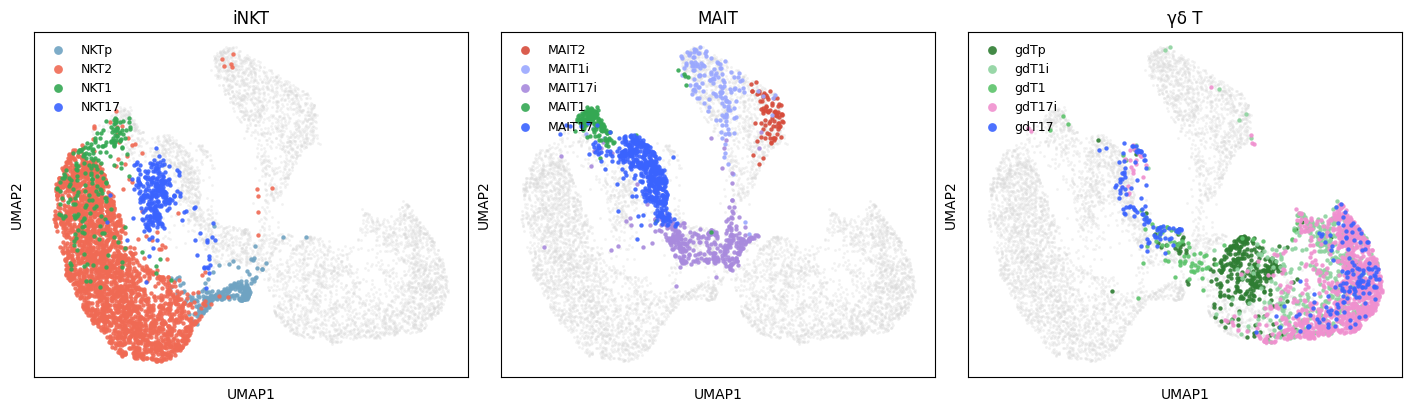

In [44]:
U_all = ad_hvg.obsm["X_umap"]  


pal_nkt  = {"NKT0":"#9BBBD5","NKTp":"#6FA3C2","NKT2":"#F06A54","NKT1":"#34A853","NKT17":"#3A63FF"}
pal_mait = {"S1":"#B08F3A","S2":"#C689E1", "MAIT2":"#D64B3B","MAIT1":"#34A853",
            "MAIT17":"#3A63FF","MAIT1i":"#9aa8ff","MAIT17i":"#a88add"}
pal_gdt  = {"gdTp":"#2E7D32","gdT1i":"#8ED39F","gdT1":"#5CC46B","gdT17i":"#F090CF","gdT17":"#3A63FF"}
L = ad_hvg.obs[LINEAGE_COL].astype(str).str.replace("γδT", "gdT")
ad_hvg.obs["_lineage_norm"] = L

def panel_shared(ax, lineage_key, order, palette, title):
    m = ad_hvg.obs["_lineage_norm"].eq(lineage_key).values

    ax.scatter(U_all[:,0], U_all[:,1], s=4, c="#D9D9D9", alpha=0.35, lw=0)
    U = U_all[m]
    subs = ad_hvg.obs.loc[m, "paper_subtype_strict"].astype(str).values
    for st in order:
        ms = (subs == st)
        if ms.sum() == 0: 
            continue
        ax.scatter(U[ms,0], U[ms,1], s=10, c=palette.get(st, "#555"), lw=0, alpha=0.9, label=st)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.legend(frameon=False, markerscale=2, fontsize=9, loc="upper left")

fig, axes = plt.subplots(1,3, figsize=(14,4), constrained_layout=True)
panel_shared(axes[0], "NKT", ["NKT0","NKTp","NKT2","NKT1","NKT17"], pal_nkt,  "iNKT")
panel_shared(axes[1], "MAIT", ["S1","S2","MAIT2","MAIT1i","MAIT17i","MAIT1","MAIT17"], pal_mait, "MAIT")
panel_shared(axes[2], "gdT",  ["gdTp","gdT1i","gdT1","gdT17i","gdT17"],pal_gdt, "γδ T")

plt.show()



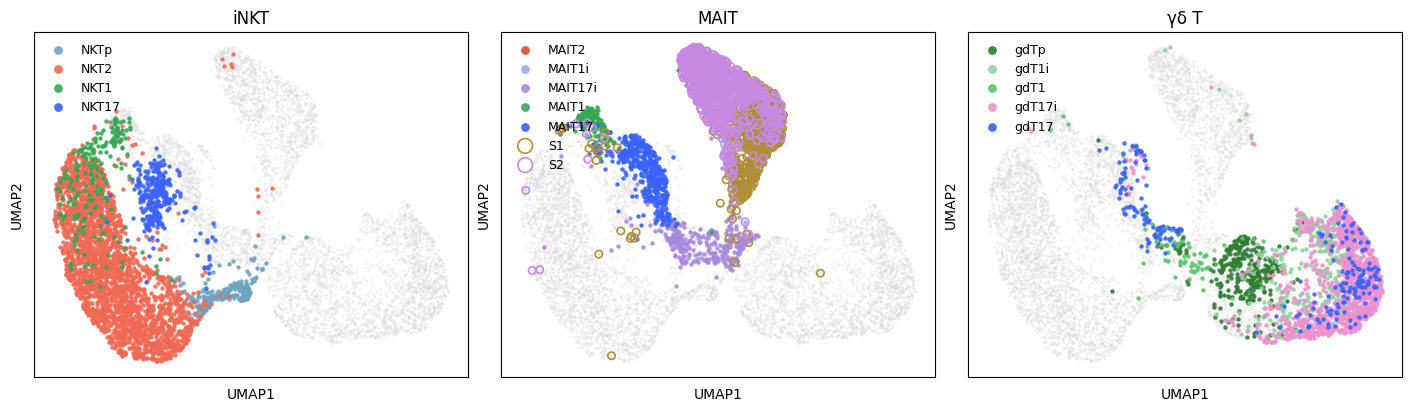

In [45]:
pal_nkt  = {"NKT0":"#9BBBD5","NKTp":"#6FA3C2","NKT2":"#F06A54","NKT1":"#34A853","NKT17":"#3A63FF"}
pal_mait = {"S1":"#B08F3A","S2":"#C689E1", "MAIT2":"#D64B3B","MAIT1i":"#9aa8ff","MAIT17i":"#a88add",
            "MAIT1":"#34A853","MAIT17":"#3A63FF"}
pal_gdt  = {"gdTp":"#2E7D32","gdT1i":"#8ED39F","gdT1":"#5CC46B","gdT17i":"#F090CF","gdT17":"#3A63FF"}
stage_pal = {"S1":"#B08F3A", "S2":"#C689E1"} 

L = ad_hvg.obs[LINEAGE_COL].astype(str).str.replace("γδT", "gdT")
ad_hvg.obs["_lineage_norm"] = L

U_all = ad_hvg.obsm["X_umap"]

def panel_shared(ax, lineage_key, order, palette, title,
                 stage_col=None, stage_palette=None, stage_order=("S1","S2"),
                 stage_size=28, stage_lw=1.2):
    m = ad_hvg.obs["_lineage_norm"].eq(lineage_key).values

    ax.scatter(U_all[:,0], U_all[:,1], s=4, c="#D9D9D9", alpha=0.35, lw=0)

    U = U_all[m]
    subs = ad_hvg.obs.loc[m, "paper_subtype_strict"].astype(str).values
    for st in order:
        ms = (subs == st)
        if ms.sum() == 0:
            continue
        ax.scatter(U[ms,0], U[ms,1], s=10, c=palette.get(st, "#555"), lw=0, alpha=0.9, label=st)

    if stage_col and stage_palette and stage_col in ad_hvg.obs.columns:
        stages = ad_hvg.obs.loc[m, stage_col].astype(str).values
        for s in stage_order:
            ms = (stages == s)
            if ms.sum() == 0:
                continue
            ax.scatter(U[ms,0], U[ms,1], s=stage_size,
                       facecolors="none", edgecolors=stage_palette.get(s, "#000"),
                       linewidths=stage_lw, label=s)

    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")

    h, l = ax.get_legend_handles_labels()
    uniq = dict(zip(l, h))
    ax.legend(uniq.values(), uniq.keys(), frameon=False, markerscale=2, fontsize=9, loc="upper left")

fig, axes = plt.subplots(1,3, figsize=(14,4), constrained_layout=True)
panel_shared(axes[0], "NKT", ["NKT0","NKTp","NKT2","NKT1","NKT17"], pal_nkt,  "iNKT")
panel_shared(axes[1], "MAIT", ["MAIT2","MAIT1i","MAIT17i","MAIT1","MAIT17"], pal_mait, "MAIT",
             stage_col="paper_stage", stage_palette=stage_pal, stage_order=("S1","S2"))
panel_shared(axes[2], "gdT",  ["gdTp","gdT1i","gdT1","gdT17i","gdT17"], pal_gdt, "γδ T")
plt.show()



In [46]:
out_path = "figures/Fig1_data_QC.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>